# Logística e SLA — atraso na entrega x nota do cliente

Responsável: Vinicius

Pergunta: pedidos atrasados recebem notas piores?

# Bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style='whitegrid')

# Dados
Só precisamos de duas tabelas: pedidos (tem as datas) e avaliações (tem a nota).

In [2]:
df_orders = pd.read_csv('olist_orders_dataset.csv',
                        parse_dates=['order_delivered_customer_date',
                                     'order_estimated_delivery_date'])
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')

df_orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13


## Filtro: só pedidos entregues
Não faz sentido medir atraso de entrega em pedido que não foi entregue.

In [3]:
df_ent = df_orders[(df_orders.order_status == 'delivered')
                   & (df_orders.order_delivered_customer_date.notna())]

print(f'Pedidos totais: {len(df_orders)}')
print(f'Pedidos entregues: {len(df_ent)}')

Pedidos totais: 99441
Pedidos entregues: 96470


## Avaliações: remover duplicadas
Alguns pedidos têm mais de uma avaliação. Mantemos uma por pedido.

In [4]:
df_rev = df_reviews.drop_duplicates(subset='order_id', keep='last')[['order_id', 'review_score']]

base = df_ent.merge(df_rev, on='order_id')
print(f'Base final: {len(base)} pedidos entregues com avaliação')

Base final: 95824 pedidos entregues com avaliação


# Cálculo do atraso

`atraso_dias` = data de entrega − prazo prometido. Positivo = atrasado.

Comparamos as **datas** (e não a hora), porque o prazo prometido vem sempre com
hora 00:00 — se comparássemos direto, quase toda entrega feita no dia prometido
apareceria como atrasada.

In [5]:
base['atraso_dias'] = (base.order_delivered_customer_date.dt.normalize()
                       - base.order_estimated_delivery_date.dt.normalize()).dt.days

base['atrasado'] = base.atraso_dias > 0
base['situacao'] = base.atrasado.map({False: 'No prazo', True: 'Atrasado'})

base[['order_id', 'atraso_dias', 'situacao', 'review_score']].head()

,order_id,atraso_dias,situacao,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-8,No prazo,4
1,53cdb2fc8bc7dce0b6741e2150273451,-6,No prazo,4
2,47770eb9100c2d0c44946d9cf07ec65d,-18,No prazo,5
3,949d5b44dbf5de918fe9c16f97b45f8a,-13,No prazo,5
4,ad21c59c0840e6cb83a9ceb5573f8159,-10,No prazo,5


In [6]:
# Faixas de atraso
base['faixa'] = ['Adiantado 4+ dias' if i <= -4
                 else 'Adiantado 1-3 dias' if i <= -1
                 else 'No prazo (dia exato)' if i == 0
                 else 'Atraso 1-3 dias' if i <= 3
                 else 'Atraso 4-7 dias' if i <= 7
                 else 'Atraso 8+ dias'
                 for i in base['atraso_dias']]

ordem = ['Adiantado 4+ dias', 'Adiantado 1-3 dias', 'No prazo (dia exato)',
         'Atraso 1-3 dias', 'Atraso 4-7 dias', 'Atraso 8+ dias']

# Números principais

In [7]:
resumo = pd.DataFrame({
    'indicador': ['Taxa de atraso (%)', 'Nota média geral',
                  'Nota média — no prazo', 'Nota média — atrasado'],
    'valor': [round(base.atrasado.mean() * 100, 2),
              round(base.review_score.mean(), 2),
              round(base[~base.atrasado].review_score.mean(), 2),
              round(base[base.atrasado].review_score.mean(), 2)]
})
resumo

,indicador,valor
0,Taxa de atraso (%),6.66
1,Nota média geral,4.16
2,Nota média — no prazo,4.29
3,Nota média — atrasado,2.27


**6,7% dos pedidos atrasam. E quando atrasam, a nota cai de 4,29 para 2,27.**

# Correlação

A nota é uma escala ordinal de 1 a 5, então usamos **Spearman** (e não Pearson).

In [8]:
rho, p_rho = stats.spearmanr(base.atraso_dias, base.review_score)
r_pb, p_pb = stats.pointbiserialr(base.atrasado, base.review_score)

print(f'Spearman (atraso em dias x nota) ....... {rho:.3f}   p = {p_rho:.1e}')
print(f'Ponto-bisserial (atrasou sim/não x nota) {r_pb:.3f}   p = {p_pb:.1e}')

Spearman (atraso em dias x nota) ....... -0.176   p = 0.0e+00
Ponto-bisserial (atrasou sim/não x nota) -0.392   p = 0.0e+00


Existe correlação **negativa e significativa**: quanto maior o atraso, menor a nota.

Repare que o coeficiente melhora bastante (−0,18 → −0,39) quando trocamos
"quantos dias de atraso" por "atrasou ou não". Isso porque a maior parte dos
pedidos chega bem adiantada, e ali a quantidade de dias não influencia a nota —
receber 20 dias antes não é melhor que receber 10. **O que importa é furar o
prazo ou não, mais do que por quantos dias.**

# Gráfico 1 — Nota média por faixa de atraso

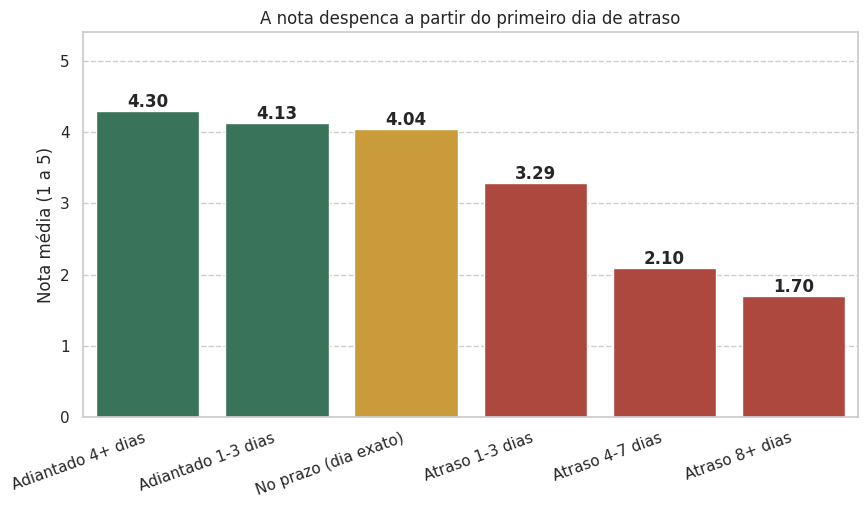

,faixa,review_score
0,Adiantado 4+ dias,4.30
1,Adiantado 1-3 dias,4.13
2,No prazo (dia exato),4.04
3,Atraso 1-3 dias,3.29
4,Atraso 4-7 dias,2.10
5,Atraso 8+ dias,1.70


In [9]:
df_faixa = (base.groupby('faixa').review_score.mean().reindex(ordem)
            .round(2).reset_index())

cores = ['#2E7D5B', '#2E7D5B', '#E0A324', '#C0392B', '#C0392B', '#C0392B']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_faixa, x='faixa', y='review_score',
                 hue='faixa', palette=cores, legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontweight='bold')
plt.ylim(0, 5.4)
plt.xlabel('')
plt.ylabel('Nota média (1 a 5)')
plt.title('A nota despenca a partir do primeiro dia de atraso')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--')
plt.show()

df_faixa

Do lado adiantado a nota quase não muda (4,30 → 4,03). Ao cruzar o prazo,
**cai de uma vez**: 3,29 → 2,10 → 1,70.

# Gráfico 2 — Distribuição das notas

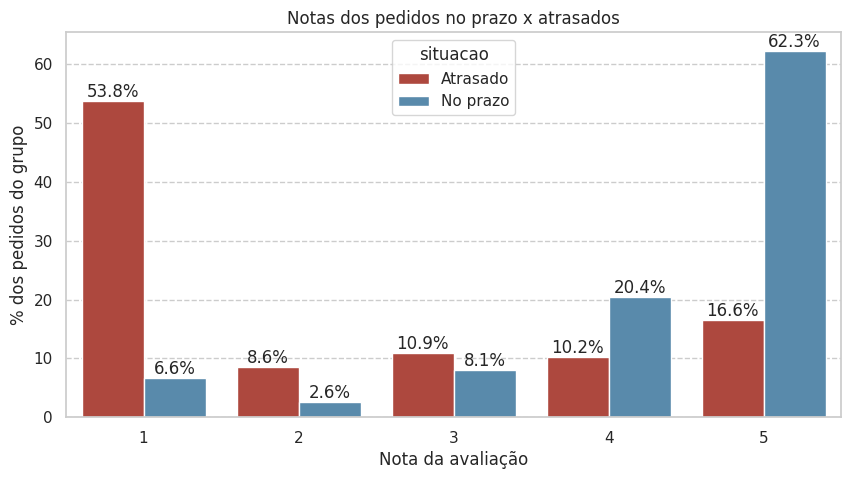

situacao,Atrasado,No prazo
review_score,,
1,53.8,6.6
2,8.6,2.6
3,10.9,8.1
4,10.2,20.4
5,16.6,62.3


In [10]:
df_dist = (base.groupby('situacao').review_score.value_counts(normalize=True)
           .mul(100).round(1).rename('pct').reset_index())

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_dist, x='review_score', y='pct', hue='situacao',
                 palette={'No prazo': '#4C8CB8', 'Atrasado': '#C0392B'})
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.xlabel('Nota da avaliação')
plt.ylabel('% dos pedidos do grupo')
plt.title('Notas dos pedidos no prazo x atrasados')
plt.grid(axis='y', linestyle='--')
plt.show()

df_dist.pivot(index='review_score', columns='situacao', values='pct')

**54% dos pedidos atrasados recebem nota 1, contra 7% dos entregues no prazo.**
É a comparação mais direta do impacto.

# Conclusão

1. **O atraso é o que mais destrói a satisfação do cliente.** A nota média cai
   de 4,29 (no prazo) para 2,27 (atrasado).
2. **54% dos pedidos atrasados recebem nota 1**, contra 7% dos entregues no
   prazo.
3. **O que importa é furar o prazo, não por quantos dias.** A nota cai de uma
   vez no primeiro dia de atraso; depois disso, atrasar mais quase não piora.

**Recomendação:** a meta operacional deve ser reduzir a *quantidade* de pedidos
atrasados, e não o número médio de dias de atraso. Todo o ganho de satisfação
está em não cruzar o prazo prometido.

**Limitações:** dados de 2016–2018. Correlação não é causalidade — atraso e nota
baixa podem ter causas em comum (categoria do produto, distância, vendedor).